In [1]:
# --- 1. Import Libraries ---
import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# ## 2. Load and Prepare Data
# We load the `Fake.csv` and `True.csv` files, assign labels (0 for Fake, 1 for Real), and combine them into a single DataFrame.

print("Loading data...")
# Ensure 'Fake.csv' and 'True.csv' are in a 'data/' directory.
try:
    fake_df = pd.read_csv('data/Fake.csv')
    true_df = pd.read_csv('data/True.csv')
except FileNotFoundError:
    print("\n" + "="*50)
    print("ERROR: Dataset not found in 'data/' directory.")
    print("Please download the dataset from Kaggle and place the CSV files in the 'data' folder.")
    print("="*50)


# Add labels
fake_df['label'] = 0
true_df['label'] = 1

# Combine and shuffle
df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Use the 'title' as our feature and rename it to 'headline'
df['headline'] = df['title']
df = df.drop(columns=['title', 'text', 'subject', 'date'])

print("Data loaded and prepared successfully.")
print(f"Total samples: {len(df)}")
df.head()


Loading data...
Data loaded and prepared successfully.
Total samples: 44898


,label,headline
0,0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,1,Trump drops Steve Bannon from National Securit...
2,1,Puerto Rico expects U.S. to lift Jones Act shi...
3,0,OOPS: Trump Just Accidentally Confirmed He Le...
4,1,Donald Trump heads for Scotland to reopen a go...


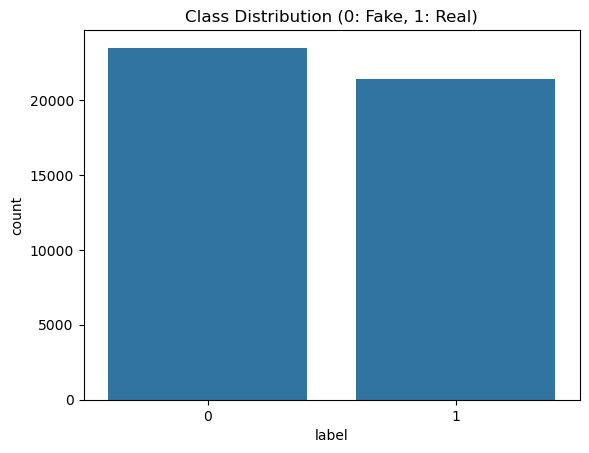

In [3]:
# ## 3. Data Exploration
# Let's quickly visualize the class distribution to ensure our dataset is balanced.

sns.countplot(x='label', data=df)
plt.title('Class Distribution (0: Fake, 1: Real)')
plt.show()


In [4]:
# ## 4. Preprocess Text Data
# Here, we convert the text headlines into numerical sequences that the neural network can understand. This involves:
# 1. **Tokenization:** Converting words into integer IDs.
# 2. **Padding:** Making all sequences a uniform length.

print("Preprocessing text data...")

# Define features (X) and labels (y)
X = df['headline'].values
y = df['label'].values

# Tokenizer configuration
vocab_size = 10000  # Max number of words to keep
oov_token = "<OOV>" # Token for words not in the vocabulary
max_length = 100    # Max length of a sequence

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X)

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(X)

# Pad sequences
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

print("Text preprocessing complete.")


Preprocessing text data...
Text preprocessing complete.


In [5]:
# ## 5. Split Data into Training and Testing Sets
# We'll use 80% of the data for training the model and 20% for testing its performance on unseen data.

print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Splitting data...
Training set shape: (35918, 100)
Testing set shape: (8980, 100)


In [6]:
# ## 6. Build the Neural Network (LSTM)
# We define the architecture of our Bidirectional LSTM model.
# - **Embedding Layer:** Creates dense vector representations of words.
# - **SpatialDropout1D:** A form of dropout to prevent overfitting.
# - **Bidirectional LSTM:** Processes sequences from both directions, capturing richer context.
# - **Dense Layer:** The output layer for binary classification.

print("Building the LSTM model...")
embedding_dim = 16

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Building the LSTM model...


C:\Python Pratice\Anacondas\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ## 7. Train the Model
# Now we fit the model to our training data. We use `EarlyStopping` to prevent overfitting by stopping the training process if the validation performance doesn't improve.

print("Training the model...")
num_epochs = 10
batch_size = 64

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=2
)


Training the model...
Epoch 1/10
562/562 - 73s - 130ms/step - accuracy: 0.9106 - loss: 0.2111 - val_accuracy: 0.9700 - val_loss: 0.0848
Epoch 2/10
562/562 - 56s - 99ms/step - accuracy: 0.9737 - loss: 0.0761 - val_accuracy: 0.9753 - val_loss: 0.0679
Epoch 3/10
562/562 - 60s - 106ms/step - accuracy: 0.9839 - loss: 0.0468 - val_accuracy: 0.9792 - val_loss: 0.0585
Epoch 4/10
562/562 - 83s - 148ms/step - accuracy: 0.9893 - loss: 0.0317 - val_accuracy: 0.9797 - val_loss: 0.0608
Epoch 5/10
562/562 - 62s - 109ms/step - accuracy: 0.9923 - loss: 0.0244 - val_accuracy: 0.9777 - val_loss: 0.0723
Epoch 6/10
562/562 - 61s - 108ms/step - accuracy: 0.9938 - loss: 0.0199 - val_accuracy: 0.9790 - val_loss: 0.0635


Evaluating the model...

Test Accuracy: 97.92%
Test Loss: 0.0585


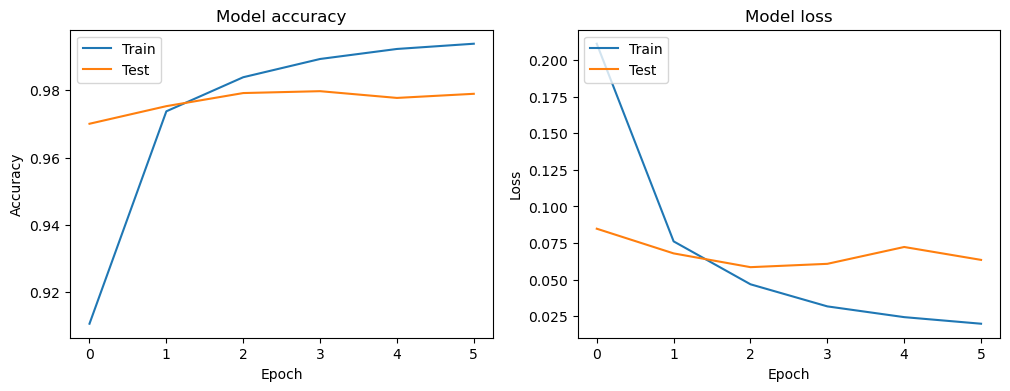

In [8]:
# ## 8. Evaluate the Model
# We check the model's final accuracy and loss on the unseen test data. We also visualize the training history.

print("Evaluating the model...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

# Plotting training history
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    
    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')
    
    plt.show()

plot_history(history)


In [9]:
# ## 9. Save the Model and Tokenizer
# Finally, we save the trained model and the tokenizer to files. These artifacts will be loaded by our Flask backend to make live predictions.

print("Saving the model and tokenizer...")

# Define the directory to save the model files
model_dir = os.path.join('backend', 'model')
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the Keras model
model.save(os.path.join(model_dir, 'fake_news_model.h5'))

# Save the tokenizer
tokenizer_json = tokenizer.to_json()
with open(os.path.join(model_dir, 'tokenizer.json'), 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

print("\n" + "="*50)
print("Training complete. Model and tokenizer saved in 'backend/model/'.")
print("You can now run the Flask backend.")
print("="*50)


Saving the model and tokenizer...

Training complete. Model and tokenizer saved in 'backend/model/'.
You can now run the Flask backend.
